# FACT Demo: Mouse hippocampus CA1

This notebook follows the Release Demo_MouseBrainCortexQuat structure while restoring the original FACT-code network inference and post-processing sequence. It uses GUI-matched direct parameters, runs FACT-guided demixing/background-removing, and keeps the static and interactive mask/trace viewers.

Data required: TIFF: data/Demo/Mouse hippocampus/Data_CA1.tif.


In [1]:
# All resources are resolved below this notebook's FACT-Code-Release root.
import gc
import sys
import time
from pathlib import Path


def _find_release_root(start: Path) -> Path:
    start = start.expanduser().resolve()
    for candidate in (start, *start.parents):
        required = (
            candidate / "IO",
            candidate / "ModelInference",
            candidate / "PostSlice",
            candidate / "PreProcessing",
            candidate / "model",
            candidate / "ModelParams" / "FACT_Modelparams.pt",
            candidate / "data" / "Demo" / "Mouse hippocampus",
        )
        if all(path.exists() for path in required):
            return candidate
    raise RuntimeError(
        "Run this notebook with the FACT-Code-Release directory as the working "
        "directory (or a child directory of it)."
    )


PROJECT_ROOT = _find_release_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Import SimpleITK before the PyTorch/MONAI stack on Windows.
import SimpleITK as sitk  # noqa: F401
import numpy as np
import torch

from IO.Read_tif import load_tiff
from ModelInference.SWInf import sliding_window_inference
from PostSlice.PostProcess_Pipeline import (
    Post_additional_morphological_blocks,
    Post_FACT_guided_backgroundremoving,
    Post_FACT_guided_demixing,
    Post_standard_spatial_consolidation,
)
from PreProcessing.Auto_normalization import estimate_display_range_video
from model.TS_Net_change import FACT_Net

# Every imported FACT package must resolve inside this Release tree.
import IO
import ModelInference
import PostSlice
import PreProcessing
import model

for _module in (IO, ModelInference, PostSlice, PreProcessing, model):
    _module_locations = list(getattr(_module, "__path__", ()))
    if not _module_locations and getattr(_module, "__file__", None):
        _module_locations = [str(Path(_module.__file__).resolve().parent)]
    if not _module_locations:
        raise RuntimeError(f"Could not locate imported package: {_module.__name__}")
    if not all(
        Path(_location).resolve().is_relative_to(PROJECT_ROOT.resolve())
        for _location in _module_locations
    ):
        raise RuntimeError(
            f"External project import detected: {_module.__name__} -> {_module_locations}"
        )

print(f"Release root: {PROJECT_ROOT}")
print(f"Python: {sys.executable}")

ROI_SIZE = (128, 64, 64)
MAX_SW_BATCH_SIZE = 32


def _is_cuda_oom(error):
    return isinstance(error, torch.cuda.OutOfMemoryError) or (
        isinstance(error, RuntimeError) and "out of memory" in str(error).lower()
    )


def _release_cuda_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# This is the helper used by the original FACT-code notebooks.
def get_auto_sw_batch_size(
    roi_size=(128, 64, 64),
    max_batch_size=32,
    reserved_ratio=0.25,
    mem_per_patch_mb=705,
):
    del roi_size
    if not torch.cuda.is_available():
        return 1
    torch.cuda.empty_cache()
    total = torch.cuda.get_device_properties(0).total_memory
    allocated = torch.cuda.memory_allocated(0)
    free = total - allocated - 1024 * 1024 * 1024
    mem_per_patch = mem_per_patch_mb * 1024 * 1024
    n = int(free * (1 - reserved_ratio) / mem_per_patch)
    batch_size = max(1, min(max_batch_size, n))
    print(
        "Auto sw_batch_size: {} (free VRAM ~{:.1f} GB)".format(
            batch_size, free / 1024**3
        )
    )
    return batch_size


Release root: FACT-Code-Release
Python: fact_py311\python.exe


fact_py311\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


### Load data

In [2]:
DATASET_NAME = "Data_CA1"
DATASET_SUBDIR = Path("Demo") / "Mouse hippocampus"
DATA_PATH = PROJECT_ROOT / "data" / DATASET_SUBDIR / f"{DATASET_NAME}.tif"
MODEL_PATH = PROJECT_ROOT / "ModelParams" / "FACT_Modelparams.pt"
data_path = str(DATA_PATH)

expected_shape = (1500, 256, 256)
NETWORK_MODE = "dense"
THRESHOLD = -2.0
if not DATA_PATH.is_file():
    raise FileNotFoundError(DATA_PATH)
if not MODEL_PATH.is_file():
    raise FileNotFoundError(MODEL_PATH)

print(f"Dataset: {DATASET_NAME}")
print(f"TIFF: {DATA_PATH.relative_to(PROJECT_ROOT)}")
print(f"Network: {NETWORK_MODE}; threshold: {THRESHOLD:g}")


Dataset: Data_CA1
TIFF: data\Demo\Mouse hippocampus\Data_CA1.tif
Network: dense; threshold: -2


In [3]:
time_start = time.perf_counter()
raw_input_img = np.asarray(load_tiff(str(DATA_PATH)), dtype=np.float32)
if raw_input_img.ndim != 3:
    raise ValueError(f"Expected a T x H x W video, got {raw_input_img.shape!r}.")
if tuple(raw_input_img.shape) != expected_shape:
    raise ValueError(
        f"TIFF shape mismatch: expected {expected_shape}, received {raw_input_img.shape}."
    )

# Same ImageJ-style automatic normalization used by the original notebooks.
norm_min, norm_max = estimate_display_range_video(raw_input_img)

norm_min, norm_max = float(norm_min), float(norm_max)
print(f"Estimated normalization range: [{norm_min:.6g}, {norm_max:.6g}]")
denom = float(norm_max - norm_min)
if not np.isfinite(norm_min) or not np.isfinite(norm_max) or denom <= 0:
    raise ValueError(f"Cannot normalize input with range [{norm_min}, {norm_max}].")
input_img = np.clip(
    (raw_input_img.astype(np.float64) - norm_min) / denom, 0.0, 1.0
).astype(np.float32)
raw_vid = input_img[:, :, :]
print(f"Loaded normalized video: shape={input_img.shape}, dtype={input_img.dtype}")
print(f"Input range before normalization: [{float(raw_input_img.min())}, {float(raw_input_img.max())}]")
print(f"Read/normalize seconds: {time.perf_counter() - time_start:.2f}")


Estimated normalization range: [33184.6, 34972.9]


Loaded normalized video: shape=(1500, 256, 256), dtype=float32
Input range before normalization: [31468.0, 39437.0]
Read/normalize seconds: 1.81


### Load FACT network

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Inference device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


def _build_fact_model(target_device):
    fact_model = FACT_Net(
        img_size=ROI_SIZE,
        in_channels=1,
        out_channels=2,
        init_dim=3,
        drop_rate=0.0,
        attn_drop_rate=0.0,
        use_checkpoint=True,
    ).to(target_device)
    weight = torch.load(
        str(MODEL_PATH), map_location="cpu", weights_only=False
    )
    fact_model.load_state_dict(weight["state_dict"])
    fact_model.eval()
    return fact_model


try:
    model = _build_fact_model(device)
except RuntimeError as exc:
    if device.type != "cuda" or not _is_cuda_oom(exc):
        raise
    print("GPU cannot hold the FACT model; falling back to CPU.")
    _release_cuda_memory()
    device = torch.device("cpu")
    model = _build_fact_model(device)

print(f"Loaded model: {MODEL_PATH.relative_to(PROJECT_ROOT)}")


Inference device: cuda:0
GPU: NVIDIA GeForce RTX 3090


Loaded model: ModelParams\FACT_Modelparams.pt


### Network Inference

In [ ]:
time_start = time.perf_counter()

# This matches the default Dense Mode inference preset: reflect-pad 64 frames on
# each temporal side, use overlap (0.6, 0.6, 0.6) with Gaussian blending, and
# crop the prediction back to the original temporal extent.
pad_width = ((64, 64), (0, 0), (0, 0))
input_img_padded = np.pad(input_img, pad_width=pad_width, mode="reflect")
input_img_tensor = torch.from_numpy(input_img_padded)
model.eval()
roi_size = (128, 64, 64)
sw_batch_size = get_auto_sw_batch_size(roi_size=roi_size, max_batch_size=32)
print(f"Starting network inference with sw_batch_size={sw_batch_size} on {device}")


def _run_inference_once(batch_size):
    test_inputs = torch.unsqueeze(torch.unsqueeze(input_img_tensor, 0), 1)
    with torch.no_grad():
        outputs = sliding_window_inference(
            test_inputs,
            roi_size,
            sw_batch_size=int(batch_size),
            predictor=model,
            overlap=[0.6, 0.6, 0.6],
            progress=True,
            mode="gaussian",
            device=torch.device("cpu"),
            sw_device=device,
        )
    # Restore the original temporal extent after the padded inference.
    outputs = outputs[:, :, 64 : 64 + input_img.shape[0], :, :]
    return outputs.detach().cpu()


while True:
    try:
        test_outputs = _run_inference_once(sw_batch_size)
        break
    except RuntimeError as exc:
        if device.type != "cuda" or not _is_cuda_oom(exc):
            raise
        _release_cuda_memory()
        if sw_batch_size > 1:
            previous_batch_size = sw_batch_size
            sw_batch_size = max(1, previous_batch_size // 2)
            print(
                f"CUDA OOM at sw_batch_size={previous_batch_size}; "
                f"retrying with sw_batch_size={sw_batch_size}."
            )
            continue
        print("CUDA OOM at sw_batch_size=1; falling back to CPU inference.")
        model = model.to(torch.device("cpu"))
        device = torch.device("cpu")
        _release_cuda_memory()
        sw_batch_size = 1
        test_outputs = _run_inference_once(sw_batch_size)
        break

thresh = float(THRESHOLD)
if not np.isclose(thresh, -2.0):
    raise ValueError(f"Expected original threshold -2, received {thresh}.")
diff = test_outputs[0, 1, :, :, :] - test_outputs[0, 0, :, :, :]
infer_mask3d = np.zeros(diff.shape, dtype=np.int16)
infer_mask3d[torch.where(diff > thresh)] = 1
diff = diff.cpu().numpy()
raw_vid = input_img[:, :, :]

if torch.cuda.is_available():
    torch.cuda.empty_cache()
del input_img_padded, input_img_tensor, test_outputs
gc.collect()
print(f"Network inference complete: infer_mask3d={infer_mask3d.shape}")
print(f"Original FACT threshold: diff > {thresh:g}")
print(f"Inference sw_batch_size used: {sw_batch_size}")
print(f"Inference device used: {device}")
print(f"Inference seconds: {time.perf_counter() - time_start:.2f}")


### Calculate STD

In [6]:
T, H, W = (int(value) for value in infer_mask3d.shape)
mask_shape_2d = (H, W)
infer_mask3d = np.asarray(infer_mask3d, dtype=np.uint8)

# Temporal-STD display image used by the Release Demo viewer.
std_raw = np.std(input_img, axis=0, dtype=np.float64)
std_min = float(std_raw.min())
std_max = float(std_raw.max())
if std_max <= std_min:
    std_img = np.zeros((H, W), dtype=np.float32)
else:
    std_img = ((std_raw - std_min) / (std_max - std_min) * 255.0).astype(np.float32)
del std_raw
gc.collect()
print(f"Postprocess mask shape: {mask_shape_2d}; frames: {T}")


Postprocess mask shape: (256, 256); frames: 1500


## Post-processing

In [7]:
# Demo-compatible spatial consolidation interface, aligned with the GUI semantics.
POST_PARAMS = {
    "max_area": 302,
    "guided_unmix_area": 170,
    "min_area": 25,
    "thresh_COM": 5.0,
    # The GUI derives COM-refine as COM + 3.
    "thresh_COM_refine": 8.0,
    "thresh_IoU": 0.7,
    "thresh_consume": (1 + 0.7) / 2,
    "thresh_acti": 4,
    "thresh_refine": 0.1,
    "num_workers": 8,
}
FACT_GUIDED_DEMIXING = True
SC2_ENABLED = True
SC2_PARAMS = [0.2, 5.0, 0.4, 2.5]
SC4_ENABLED = True
SC4_MIN_AREA = 40

post_start = time.perf_counter()
masks_final, timestamps_final = Post_standard_spatial_consolidation(
    infer_mask3d,
    mask_shape_2d=mask_shape_2d,
    min_area=POST_PARAMS["min_area"],
    max_area=POST_PARAMS["max_area"],
    thresh_com=POST_PARAMS["thresh_COM"],
    thresh_com_refine=POST_PARAMS["thresh_COM_refine"],
    thresh_refine=POST_PARAMS["thresh_refine"],
    thresh_iou=POST_PARAMS["thresh_IoU"],
    thresh_consume=POST_PARAMS["thresh_consume"],
    thresh_acti=POST_PARAMS["thresh_acti"],
    num_workers=POST_PARAMS["num_workers"],
    empty_safe=True,
)

masks_final = (masks_final.tocsr() > 0).astype(np.int64)
print(f"Spatial postprocess complete: masks={masks_final.shape[0]}")
print(f"Postprocess seconds: {time.perf_counter() - post_start:.2f}")


Finding mask pairs
Calculating transfered masks


Spatial postprocess complete: masks=187
Postprocess seconds: 2.74


In [8]:
# Match the GUI order: guided demixing -> enabled morphology (SC2, SC4)
# -> surround-background removal with overlap demixing.
demix_start = time.perf_counter()
if masks_final.shape[0] == 0:
    traces_roi = np.zeros((0, T), dtype=np.float32)
    traces_background = np.zeros((0, T), dtype=np.float32)
    traces_final = np.zeros((0, T), dtype=np.float32)
    sources = np.zeros((0,), dtype=bool)
    alpha_nnls = np.zeros((0,), dtype=np.float32)
    print("No masks after spatial consolidation; GUI-aligned downstream stages skipped.")
else:
    masks_final, traces_final, sources = Post_FACT_guided_demixing(
        masks_final,
        infer_mask3d,
        input_img,
        mask_shape_2d,
        enabled=FACT_GUIDED_DEMIXING,
        max_area=POST_PARAMS["guided_unmix_area"],
        thresh_refine=POST_PARAMS["thresh_refine"],
        min_area=POST_PARAMS["min_area"],
        verbose=0,
        return_full_traces=True,
        return_sources=True,
        frame_rate=15.0,
    )
    masks_final = (masks_final.tocsr() > 0).astype(np.int64)
    print(f"FACT-guided demixing: masks={masks_final.shape[0]}")

    masks_final, traces_final, sources = Post_additional_morphological_blocks(
        masks_final,
        mask_shape_2d,
        traces=traces_final,
        sources=sources,
        sc2=SC2_ENABLED,
        sc2_params=SC2_PARAMS,
        sc4=SC4_ENABLED,
        sc4_min_area=SC4_MIN_AREA,
        copy_inputs=True,
    )
    masks_final = (masks_final.tocsr() > 0).astype(np.int64)

    bg_results = Post_FACT_guided_backgroundremoving(
        masks_final,
        traces_final,
        sources,
        infer_mask3d=infer_mask3d,
        input_img=input_img,
        mask_shape_2d=mask_shape_2d,
        run_overlap_demix=True,
        binarize_final=True,
    )
    masks_final = (bg_results["masks_final"].tocsr() > 0).astype(np.int64)
    traces_roi = np.asarray(bg_results["traces_cell"], dtype=np.float32)
    traces_background = np.asarray(bg_results["traces_bg"], dtype=np.float32)
    traces_final = np.asarray(bg_results["traces_final"], dtype=np.float32)
    sources = np.asarray(bg_results["sources"], dtype=bool).reshape(-1)
    alpha_nnls = np.asarray(bg_results["alpha_nnls"], dtype=np.float32).reshape(-1)

if traces_final.shape != (masks_final.shape[0], T):
    raise RuntimeError(
        f"Trace/mask shape mismatch: masks={masks_final.shape}, traces={traces_final.shape}"
    )
if not np.all(np.isfinite(traces_final)):
    raise RuntimeError("FACT-guided background-removing produced non-finite traces.")

gc.collect()
print(f"Enabled morphology (GUI order): SC2=True, SC4=True; final={masks_final.shape[0]}")
print(f"FACT-guided background-removing (Demo wrapper): masks={masks_final.shape[0]}")
print(f"Trace shapes: ROI={traces_roi.shape}, background={traces_background.shape}, final={traces_final.shape}")
print(f"Demixing/background seconds: {time.perf_counter() - demix_start:.2f}")


FACT-guided demixing: masks=285


Enabled morphology (GUI order): SC2=True, SC4=True; final=234
FACT-guided background-removing (Demo wrapper): masks=234
Trace shapes: ROI=(234, 1500), background=(234, 1500), final=(234, 1500)
Demixing/background seconds: 147.94


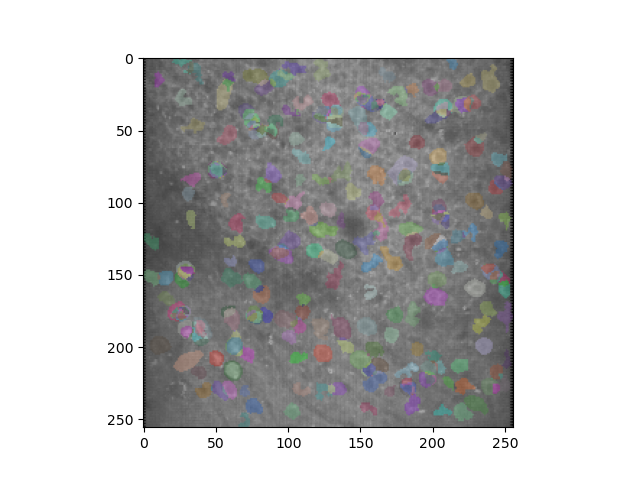

In [9]:
import matplotlib.pyplot as plt
from PostSlice.UI.Drawmap import draw_mask_colormap
from UI.Combine import combine_masks

# ------------------------------------------------ Show time ---------------------------------------------------
showmap = draw_mask_colormap(masks_final, mask_shape_2d)
show_combined = combine_masks(showmap, std_img, alpha=0.3, brightness_factor=0.8, mask_threshold=1)
plt.figure(dpi=100)
plt.imshow(show_combined)
plt.show()


## Interactive exhibition of masks and traces

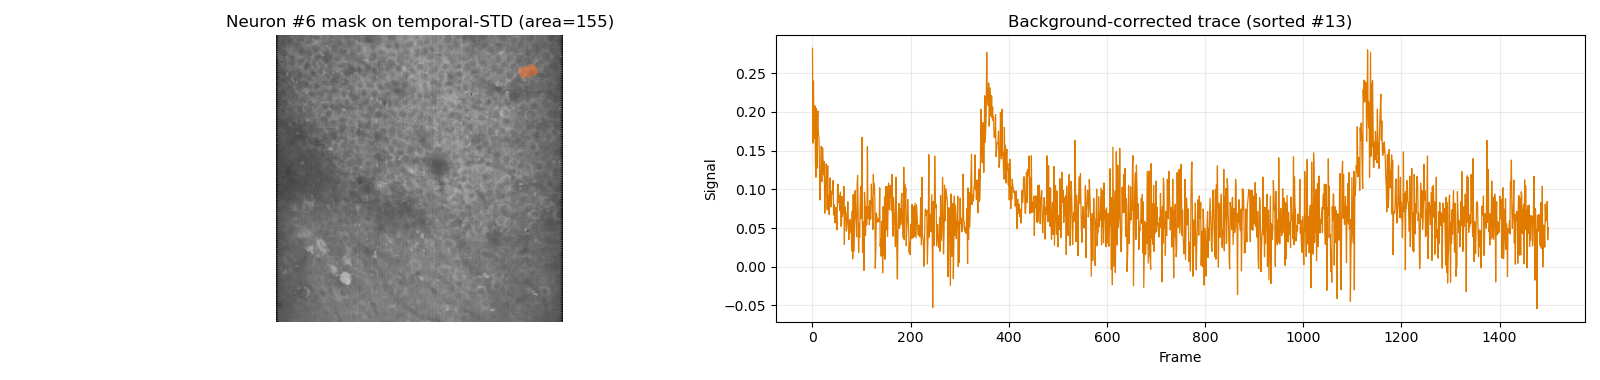

In [10]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display


def _single_mask_flat(mask_array, row_index):
    row = mask_array.getrow(int(row_index))
    return np.asarray(row.toarray()).ravel()


def _warm_color(row_index):
    # Deterministic warm hue, so re-running a cell keeps the same appearance.
    hue = (0.035 + 0.11 * ((int(row_index) * 37) % 101) / 100.0) % 1.0
    return (mcolors.hsv_to_rgb((hue, 0.90, 1.0)) * 255.0).astype(np.float32)


def _overlay_for_row(row_index):
    mask = _single_mask_flat(masks_final, row_index).reshape(mask_shape_2d) > 0
    # Match the original notebook's darker std background.
    gray = np.clip(std_img * 0.8, 0.0, 255.0).astype(np.float32)
    overlay = np.repeat(gray[..., None], 3, axis=2)
    color = _warm_color(row_index)
    overlay[mask] = 0.5 * overlay[mask] + 0.5 * color
    return np.clip(overlay, 0, 255).astype(np.uint8), mask


mask_areas = np.asarray(masks_final.getnnz(axis=1)).ravel()
sorted_neuron_indices = np.argsort(mask_areas)[::-1]
neuron_count = int(masks_final.shape[0])


def show_single_neuron(sorted_idx):
    sorted_idx = int(sorted_idx)
    neuron_idx = int(sorted_neuron_indices[sorted_idx])
    overlay, mask = _overlay_for_row(neuron_idx)
    trace = np.asarray(traces_final[neuron_idx]).ravel()
    fig, axes = plt.subplots(1, 2, figsize=(16, 3.8))
    axes[0].imshow(overlay)
    axes[0].set_title(
        f"Neuron #{neuron_idx} mask on temporal-STD (area={int(mask_areas[neuron_idx])})"
    )
    axes[0].axis("off")
    axes[1].plot(trace, lw=0.9, color="#e07b00")
    axes[1].set_title(f"Background-corrected trace (sorted #{sorted_idx})")
    axes[1].set_xlabel("Frame")
    axes[1].set_ylabel("Signal")
    axes[1].grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


if neuron_count == 0:
    print("No masks were produced; interactive viewer is unavailable.")
else:
    # Render the purple-boxed CA1 ROI immediately above its nearby large
    # neighbor, then expose the same view through the interactive slider.
    default_sorted_idx = 13 if neuron_count > 13 else max(0, neuron_count - 1)
    show_single_neuron(default_sorted_idx)
    neuron_slider = widgets.IntSlider(
        value=default_sorted_idx,
        min=0,
        max=neuron_count - 1,
        step=1,
        description="Sorted#",
        continuous_update=False,
    )
    viewer_output = widgets.interactive_output(
        show_single_neuron, {"sorted_idx": neuron_slider}
    )
    display(widgets.VBox([neuron_slider, viewer_output]))


#### Save masks and traces (Optional)


In [ ]:
# Fetch data filename and save path
import os

data_dir = os.path.split(data_path)[0]
data_name = os.path.splitext(os.path.split(data_path)[1])[0]
print(f'data dir is "{data_dir}", data name is "{data_name}"')

infer_dir = data_dir
save_filepth = os.path.join(infer_dir, data_name)


In [ ]:
# Save final masks and traces (Optional)
# This cell intentionally keeps only the Release MAT exporter.
print(f"MAT output stem: {save_filepth}")


In [ ]:
from IO.Save_mat import savemask_mat_withtrace

savepth_mat = save_filepth + "_FACT_masks_trace.mat"
savemask_mat_withtrace(
    masks=(masks_final.tocsr() > 0).astype(np.int64),
    maskshape_2d=mask_shape_2d,
    traces=np.asarray(traces_final, dtype=np.float32),
    save_pth=save_filepth,
    maskfrom="FACT",
)
print(f"Saved masks and traces: {savepth_mat}")
